MATCHING SUMMARY
Detected sources: 13
Reference stars: 1917

Closest matches:
Source  0 | inst_mag=-16.00 | catalog_mag= 10.19 | sep=  4.29 arcsec
Source  1 | inst_mag=-14.52 | catalog_mag= 12.69 | sep=  0.33 arcsec
Source  2 | inst_mag=-13.98 | catalog_mag= 12.77 | sep=  1.57 arcsec
Source  3 | inst_mag=-15.03 | catalog_mag= 12.07 | sep=  0.47 arcsec
Source  4 | inst_mag=-15.29 | catalog_mag= 11.61 | sep=  2.27 arcsec
Source  5 | inst_mag=-14.89 | catalog_mag= 12.02 | sep=  3.60 arcsec
Source  6 | inst_mag=-12.71 | catalog_mag= 13.53 | sep=  3.32 arcsec
Source  7 | inst_mag=-11.76 | catalog_mag= 15.87 | sep= 30.90 arcsec
Source  8 | inst_mag=-15.54 | catalog_mag= 11.39 | sep=  2.78 arcsec
Source  9 | inst_mag=-11.68 | catalog_mag= 16.05 | sep= 12.22 arcsec
Source 10 | inst_mag=-11.76 | catalog_mag= 13.91 | sep=  1.62 arcsec
Source 11 | inst_mag=-12.38 | catalog_mag= 13.32 | sep=  4.20 arcsec
Source 12 | inst_mag=-14.06 | catalog_mag= 12.86 | sep=  3.04 arcsec

SEPARATION STATISTICS
Mi

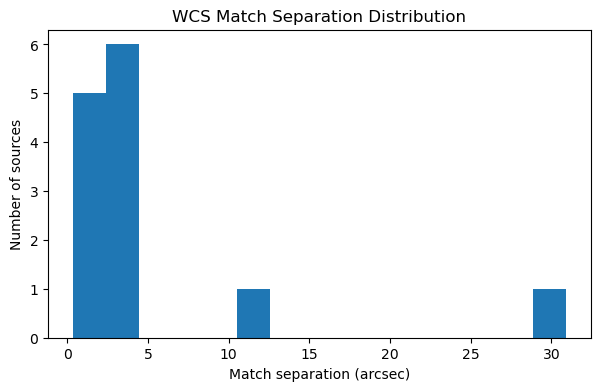


Good matches (<25"): 12
Mean zeropoint: 26.686560544239924
Zeropoint scatter: 0.592712013291967


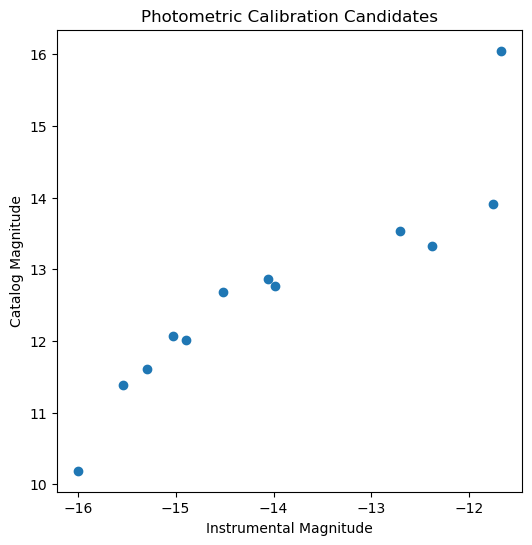

In [1]:
from astropy.table import Table
from astropy.io import fits
from astropy.wcs import WCS
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load catalogs
sources = Table.read("../outputs/tables/segmentation_sources.ecsv")
refcat = Table.read("../outputs/tables/reference_catalog.ecsv")

# Find FITS file
session_dir = Path("../data/raw/v854_cen_dasch")
fits_files = list(session_dir.rglob("*.fits"))

if len(fits_files) == 0:
    raise FileNotFoundError("No FITS files found")

cutout_path = fits_files[0]

# Load WCS
hdul = fits.open(cutout_path)
wcs = WCS(hdul[0].header)

# Convert detections to sky coordinates
detected_coords = wcs.pixel_to_world(
    sources["xcentroid"],
    sources["ycentroid"]
)

# Catalog coordinates
catalog_coords = refcat["pos"]

# Match
idx, sep2d, _ = detected_coords.match_to_catalog_sky(catalog_coords)
matches = refcat[idx]

# Summary
print("=" * 60)
print("MATCHING SUMMARY")
print("=" * 60)

print("Detected sources:", len(sources))
print("Reference stars:", len(refcat))

print("\nClosest matches:")
for i in range(len(sources)):
    print(
        f"Source {i:2d} | "
        f"inst_mag={sources['inst_mag'][i]:6.2f} | "
        f"catalog_mag={matches['stdmag'][i]:6.2f} | "
        f"sep={sep2d[i].arcsec:6.2f} arcsec"
    )

# Match quality statistics
print("\n" + "=" * 60)
print("SEPARATION STATISTICS")
print("=" * 60)

print("Minimum separation:", np.min(sep2d.arcsec))
print("Median separation :", np.median(sep2d.arcsec))
print("Maximum separation:", np.max(sep2d.arcsec))

for limit in [5, 10, 15, 20, 25]:
    n = np.sum(sep2d.arcsec < limit)
    print(f"Matches within {limit:2d}\" : {n}")

# Histogram
plt.figure(figsize=(7,4))
plt.hist(sep2d.arcsec, bins=15)
plt.xlabel("Match separation (arcsec)")
plt.ylabel("Number of sources")
plt.title("WCS Match Separation Distribution")
plt.show()

# Good matches
good = sep2d.arcsec < 25

print("\nGood matches (<25\"):", np.sum(good))

if np.sum(good) > 0:
    zp = matches["stdmag"][good] - sources["inst_mag"][good]

    print("Mean zeropoint:", np.mean(zp))
    print("Zeropoint scatter:", np.std(zp))

    plt.figure(figsize=(6,6))
    plt.scatter(
        sources["inst_mag"][good],
        matches["stdmag"][good]
    )
    plt.xlabel("Instrumental Magnitude")
    plt.ylabel("Catalog Magnitude")
    plt.title("Photometric Calibration Candidates")
    plt.show()